In [ ]:
import pandas as pd
import numpy as np
import json
import os
import warnings
import time
from datetime import datetime
warnings.filterwarnings('ignore')

from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from category_encoders import TargetEncoder
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    confusion_matrix, accuracy_score, f1_score
)
import seaborn as sns
import matplotlib.pyplot as plt

print("Libraries loaded")

from pathlib import Path
import sys


PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

Libraries loaded


In [ ]:
def load_train_test(train_path, test_path, target_col='is_fraud'):
    # Loading and Splitting the data into X (features) and y (target)
    train_df = pd.read_csv(train_path)
    test_df = pd.read_csv(test_path)
    X_train, y_train = train_df.drop(columns=[target_col]), train_df[target_col]
    X_test, y_test = test_df.drop(columns=[target_col]), test_df[target_col]
    print(f"Train: {X_train.shape} | Test: {X_test.shape}")
    return X_train, y_train, X_test, y_test

In [ ]:
def apply_ordinal_encoding(X_train, X_test, categorical_cols):
    # Converting categorical variables to ordinal integers
    encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X_train_enc = X_train.copy()
    X_test_enc = X_test.copy()
    X_train_enc[categorical_cols] = encoder.fit_transform(X_train[categorical_cols])
    X_test_enc[categorical_cols] = encoder.transform(X_test[categorical_cols])
    return X_train_enc, X_test_enc

In [ ]:
def apply_onehot_encoding(X_train, X_test, categorical_cols):
    # Converting categorical variables to binary dummy variables
    X_train_enc = pd.get_dummies(X_train.copy(), columns=categorical_cols, drop_first=True)
    X_test_enc = pd.get_dummies(X_test.copy(), columns=categorical_cols, drop_first=True)
    X_train_enc, X_test_enc = X_train_enc.align(X_test_enc, join='left', axis=1, fill_value=0)
    return X_train_enc, X_test_enc

In [ ]:
def apply_target_encoding(X_train, X_test, y_train, categorical_cols, smoothing=1.0):
    # Encoding categories based on target variable statistics
    encoder = TargetEncoder(cols=categorical_cols, smoothing=smoothing)
    X_train_enc = X_train.copy()
    X_test_enc = X_test.copy()
    X_train_enc[categorical_cols] = encoder.fit_transform(X_train[categorical_cols], y_train)
    X_test_enc[categorical_cols] = encoder.transform(X_test[categorical_cols])
    return X_train_enc, X_test_enc

In [ ]:
def apply_label_encoding(X_train, X_test, categorical_cols):
    # Converting categorical variables to numeric labels
    X_train_enc = X_train.copy()
    X_test_enc = X_test.copy()
    for col in categorical_cols:
        le = LabelEncoder()
        X_train_enc[col] = le.fit_transform(X_train[col].astype(str))
        X_test_enc[col] = X_test[col].astype(str).map(lambda x: le.transform([x])[0] if x in le.classes_ else -1)
    return X_train_enc, X_test_enc

In [ ]:
def calculate_scale_pos_weight(y_train):
    # Calculating class weight to handle imbalanced dataset
    neg = (y_train == 0).sum()
    pos = (y_train == 1).sum()
    weight = neg / pos
    print(f"Scale Pos Weight: {weight:.2f} | Neg: {neg} | Pos: {pos}")
    return weight

In [ ]:
def train_xgboost_model(X_train, y_train, scale_pos_weight=None, random_state=42):
    X_train_final = X_train.copy()
    y_train_final = y_train.copy()

    # Initialize XGBoost model with optimized parameters
    model = XGBClassifier(
        objective='binary:logistic',
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight, # XGBoost's built-in imbalance handling
        random_state=random_state,
        eval_metric='aucpr', # Precision-Recall AUC for imbalanced data
        n_jobs=-1,
        verbosity=0
    )

    print(f"\nTraining XGBoost Model...")
    print(f"  n_estimators: 300")
    print(f"  learning_rate: 0.05")
    print(f"  max_depth: 6")
    print(f"  scale_pos_weight: {scale_pos_weight}")

    start_time = time.time()
    model.fit(X_train_final, y_train_final)
    training_time = time.time() - start_time

    print(f"Model training completed in {training_time:.2f} seconds ({training_time/60:.2f} minutes)")

    return model, X_train_final, y_train_final, training_time

In [ ]:
def evaluate_and_save_results(model, X_train, X_test, y_train, y_test,
                               model_name="xgboost", encoder_type="ordinal",
                               training_time=0, scale_pos_weight=None):
    print(f"\nEvaluating {model_name} model...")

    # Generate predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Calculating metrics
    report = classification_report(y_test, y_pred, output_dict=True)
    roc_auc = roc_auc_score(y_test, y_prob)
    avg_precision = average_precision_score(y_test, y_prob)
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # ROC Curve
    fpr, tpr, roc_thresholds = roc_curve(y_test, y_prob)

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    # Additional metrics
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0  # Positive Predictive Value
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # Negative Predictive Value

    # Precision-Recall Curve
    precision, recall, pr_thresholds = precision_recall_curve(y_test, y_prob)

    # Feature Importance (top 20)
    feature_importance = pd.DataFrame({
        'feature': X_test.columns,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False).head(20)

    results = {
        "encoding_method": encoder_type,
        "performance_metrics": {
            "accuracy": round(float(accuracy), 4),
            "f1_score": round(float(f1), 4),
            "roc_auc": round(float(roc_auc), 4),
            "average_precision": round(float(avg_precision), 4),
            "sensitivity_recall": round(float(sensitivity), 4),
            "specificity": round(float(specificity), 4),
            "positive_predictive_value": round(float(ppv), 4),
            "negative_predictive_value": round(float(npv), 4)
        },
        "classification_report": report,
        "confusion_matrix": {
            "labels": ["non_fraud", "fraud"],
            "matrix": cm.tolist(),
            "true_negatives": int(tn),
            "false_positives": int(fp),
            "false_negatives": int(fn),
            "true_positives": int(tp),
            "fraud_detection_rate": round(float(sensitivity), 4),
            "false_alarm_rate": round(fp / (fp + tn), 4) if (fp + tn) > 0 else 0
        },
        "roc_curve": {
            "fpr": fpr.tolist(),
            "tpr": tpr.tolist(),
            "thresholds": roc_thresholds.tolist()
        },
        "precision_recall_curve": {
            "precision": precision.tolist(),
            "recall": recall.tolist(),
            "thresholds": pr_thresholds.tolist()
        },
        "feature_importance_top20": feature_importance.to_dict('records')
    }

    print(f"\nKey Metrics:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    print(f"  ROC-AUC: {roc_auc:.4f}")
    print(f"  Avg Precision: {avg_precision:.4f}")
    print(f"  Sensitivity: {sensitivity:.4f}")
    print(f"  Specificity: {specificity:.4f}")

    return results

In [ ]:
def visualize_results(results, title_prefix="XGBoost", model=None, X_train=None, y_train=None):
    # ROC Curve
    plt.figure(figsize=(10, 6))
    fpr = results["roc_curve"]["fpr"]
    tpr = results["roc_curve"]["tpr"]
    roc_auc = results["performance_metrics"]["roc_auc"]

    plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.4f})", linewidth=2.5, color='#1f77b4')
    plt.plot([0, 1], [0, 1], linestyle='--', label='Random Classifier', color='gray', linewidth=1.5)
    plt.xlabel("False Positive Rate", fontsize=12, fontweight='bold')
    plt.ylabel("True Positive Rate", fontsize=12, fontweight='bold')
    plt.title(f"{title_prefix} - ROC Curve", fontsize=13, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Precision-Recall Curve
    plt.figure(figsize=(10, 6))
    precision = results["precision_recall_curve"]["precision"]
    recall = results["precision_recall_curve"]["recall"]
    avg_precision = results["performance_metrics"]["average_precision"]

    plt.plot(recall, precision, label=f"PR Curve (AP = {avg_precision:.4f})", linewidth=2.5, color='#ff7f0e')
    plt.xlabel("Recall", fontsize=12, fontweight='bold')
    plt.ylabel("Precision", fontsize=12, fontweight='bold')
    plt.title(f"{title_prefix} - Precision-Recall Curve", fontsize=13, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Confusion Matrix
    plt.figure(figsize=(8, 7))
    cm = np.array(results["confusion_matrix"]["matrix"])
    labels = results["confusion_matrix"]["labels"]

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels,
                cbar_kws={'label': 'Count'}, annot_kws={'size': 14, 'weight': 'bold'})
    plt.xlabel("Predicted", fontsize=12, fontweight='bold')
    plt.ylabel("Actual", fontsize=12, fontweight='bold')
    plt.title(f"{title_prefix} - Confusion Matrix", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Feature Importance (Top 15)
    if "feature_importance_top20" in results:
        plt.figure(figsize=(10, 8))
        features = results["feature_importance_top20"][:15]
        feature_names = [f["feature"][:20] for f in features]
        importance_scores = [f["importance"] for f in features]

        colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(feature_names)))
        plt.barh(range(len(feature_names)), importance_scores, color=colors, edgecolor='black')
        plt.yticks(range(len(feature_names)), feature_names, fontsize=10)
        plt.xlabel("Importance Score", fontsize=12, fontweight='bold')
        plt.title(f"{title_prefix} - Top 15 Feature Importance", fontsize=13, fontweight='bold')
        plt.gca().invert_yaxis()
        plt.grid(True, alpha=0.3, axis='x')
        plt.tight_layout()
        plt.show()

    # Performance Metrics Summary
    plt.figure(figsize=(12, 6))
    metrics_data = {
        'Accuracy': results["performance_metrics"]["accuracy"],
        'Precision': results["classification_report"]["1"]["precision"],
        'Recall': results["performance_metrics"]["sensitivity_recall"],
        'F1-Score': results["performance_metrics"]["f1_score"],
        'ROC-AUC': results["performance_metrics"]["roc_auc"],
        'Avg Precision': results["performance_metrics"]["average_precision"],
        'Specificity': results["performance_metrics"]["specificity"]
    }

    colors_metrics = ['#d62728' if v < 0.5 else '#2ca02c' if v > 0.9 else '#ff7f0e'
                      for v in metrics_data.values()]
    bars = plt.bar(range(len(metrics_data)), list(metrics_data.values()), color=colors_metrics, alpha=0.8, edgecolor='black', linewidth=1.5)
    plt.xticks(range(len(metrics_data)), list(metrics_data.keys()), fontsize=11, rotation=45, ha='right')
    plt.ylabel("Score", fontsize=12, fontweight='bold')
    plt.title(f"{title_prefix} - Performance Metrics Summary", fontsize=13, fontweight='bold')
    plt.ylim([0, 1.05])
    plt.grid(True, alpha=0.3, axis='y')

    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.show()

    # Learning Curve
    if model is not None and X_train is not None and y_train is not None:
        from sklearn.model_selection import learning_curve

        plt.figure(figsize=(10, 6))
        train_sizes, train_scores, val_scores = learning_curve(
            model, X_train, y_train, cv=5,
            train_sizes=np.linspace(0.1, 1.0, 10),
            scoring='roc_auc', n_jobs=-1
        )

        train_mean = np.mean(train_scores, axis=1)
        train_std = np.std(train_scores, axis=1)
        val_mean = np.mean(val_scores, axis=1)
        val_std = np.std(val_scores, axis=1)

        plt.plot(train_sizes, train_mean, 'o-', linewidth=2, label='Training Score', color='#2ca02c')
        plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color='#2ca02c')
        plt.plot(train_sizes, val_mean, 's-', linewidth=2, label='Validation Score', color='#d62728')
        plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2, color='#d62728')

        plt.xlabel("Training Set Size", fontsize=12, fontweight='bold')
        plt.ylabel("ROC-AUC Score", fontsize=12, fontweight='bold')
        plt.title(f"{title_prefix} - Learning Curve", fontsize=13, fontweight='bold')
        plt.legend(fontsize=11)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    # Summary of Evaluation
    tn = results["confusion_matrix"]["true_negatives"]
    fp = results["confusion_matrix"]["false_positives"]
    fn = results["confusion_matrix"]["false_negatives"]
    tp = results["confusion_matrix"]["true_positives"]

    print(f"\n{'='*60}")
    print(f"EVALUATION SUMMARY - {title_prefix}")
    print(f"{'='*60}")
    print(f"Confusion Matrix Breakdown:")
    print(f"  True Negatives:  {tn:>8} | False Positives: {fp:>8}")
    print(f"  False Negatives: {fn:>8} | True Positives:  {tp:>8}")
    print(f"\nKey Metrics:")
    print(f"  Sensitivity (Recall):  {tp/(tp+fn):.4f} (Fraud Detection Rate)")
    print(f"  Specificity:           {tn/(tn+fp):.4f} (Non-Fraud Identification)")
    print(f"  Precision:             {tp/(tp+fp):.4f} (Fraud Alarm Accuracy)")
    print(f"  False Alarm Rate:      {fp/(fp+tn):.4f}")
    print(f"  ROC-AUC:               {results['performance_metrics']['roc_auc']:.4f}")
    print(f"  Average Precision:     {results['performance_metrics']['average_precision']:.4f}")
    print(f"{'='*60}\n")

In [ ]:

def visualize_encoder_comparison(comparison_results):
    # Creating heat map to compare performance across different encoders

    # Extract metrics for each encoder
    encoders = []
    accuracies = []
    f1_scores = []
    roc_aucs = []
    avg_precisions = []

    for encoder_name, data in comparison_results.items():
        metrics = data["results"]["performance_metrics"]
        encoders.append(encoder_name)
        accuracies.append(metrics["accuracy"])
        f1_scores.append(metrics["f1_score"])
        roc_aucs.append(metrics["roc_auc"])
        avg_precisions.append(metrics["average_precision"])

    # heatmap data
    heatmap_data = np.array([
        accuracies,
        f1_scores,
        roc_aucs,
        avg_precisions
    ])

    # heatmap
    plt.figure(figsize=(10, 6))
    sns.heatmap(heatmap_data, annot=True, fmt='.4f', cmap='RdYlGn',
                xticklabels=encoders, yticklabels=['Accuracy', 'F1-Score', 'ROC-AUC', 'Avg Precision'],
                cbar_kws={'label': 'Score'}, vmin=0, vmax=1, annot_kws={'size': 12, 'weight': 'bold'})
    plt.title("Encoder Comparison - Performance Metrics Heatmap", fontsize=13, fontweight='bold')
    plt.xlabel("Encoding Method", fontsize=12, fontweight='bold')
    plt.ylabel("Metrics", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()


def compare_encoders(X_train, X_test, y_train, y_test, categorical_cols, scale_pos_weight):
    encoders = {
        "Ordinal": apply_ordinal_encoding,
        "OneHot": apply_onehot_encoding,
        "Label": apply_label_encoding,
    }

    comparison_results = {}

    print("ENCODER COMPARISON")
    # Testing Ordinal, OneHot, and Label encoders
    for encoder_name, encoder_func in encoders.items():
        print(f"Testing Encoder: {encoder_name}")

        # Apply encoding
        X_train_enc, X_test_enc = encoder_func(X_train, X_test, categorical_cols)

        # Train model
        model, _, _, training_time = train_xgboost_model(
            X_train_enc, y_train,
            scale_pos_weight=scale_pos_weight
        )

        # Evaluate
        results = evaluate_and_save_results(
            model, X_train_enc, X_test_enc, y_train, y_test,
            model_name=f"XGBoost_{encoder_name}",
            encoder_type=encoder_name,
            training_time=training_time,
            scale_pos_weight=scale_pos_weight
        )

        comparison_results[encoder_name] = {
            "model": model,
            "results": results,
            "X_train_enc": X_train_enc,
            "X_test_enc": X_test_enc
        }

    # Test Target Encoder
    print(f"Testing Encoder: Target")
    X_train_enc, X_test_enc = apply_target_encoding(X_train, X_test, y_train, categorical_cols)
    model, _, _, training_time = train_xgboost_model(
        X_train_enc, y_train,
        scale_pos_weight=scale_pos_weight
    )
    results = evaluate_and_save_results(
        model, X_train_enc, X_test_enc, y_train, y_test,
        model_name="XGBoost_Target",
        encoder_type="Target",
        training_time=training_time,
        scale_pos_weight=scale_pos_weight
    )
    comparison_results["Target"] = {
        "model": model,
        "results": results,
        "X_train_enc": X_train_enc,
        "X_test_enc": X_test_enc
    }

    # Summary comparison table
    print("ENCODER COMPARISON SUMMARY")
    print(f"{'Encoder':<15} {'Accuracy':<12} {'F1-Score':<12} {'ROC-AUC':<12} {'Avg Precision':<15}")

    for encoder_name, data in comparison_results.items():
        metrics = data["results"]["performance_metrics"]
        print(f"{encoder_name:<15} {metrics['accuracy']:<12.4f} {metrics['f1_score']:<12.4f} "
              f"{metrics['roc_auc']:<12.4f} {metrics['average_precision']:<15.4f}")

    # Select best encoder based on ROC-AUC
    best_encoder = max(comparison_results.items(),
                       key=lambda x: x[1]["results"]["performance_metrics"]["roc_auc"])

    print(f"BEST ENCODER: {best_encoder[0]} (ROC-AUC: {best_encoder[1]['results']['performance_metrics']['roc_auc']:.4f})")

    return comparison_results, best_encoder[0]

---

## 2. Load Data

In [ ]:
TRAIN_PATH = PROJECT_ROOT / "Data Understanding, Exploration & Feature Engineering/Dataset & Feature Engineered data/transactions_pre_processed.csv"
TEST_PATH = PROJECT_ROOT / "Data Understanding, Exploration & Feature Engineering/Dataset & Feature Engineered data/transactions_pre_processed.csv"
SPLIT_DATA = True
TEST_SIZE = 0.2
RANDOM_STATE = 42

if SPLIT_DATA:
    print("Loading single dataset and splitting into train/test...")
    df = pd.read_csv(TRAIN_PATH)
    print(f"Dataset shape: {df.shape}")

    TARGET_COL = 'is_fraud'

    if TARGET_COL not in df.columns:
        print(f"\nAvailable columns: {df.columns.tolist()}")
        print("\n Please update TARGET_COL variable with the correct target column name")
    else:
        train_df, test_df = train_test_split(
            df, test_size=TEST_SIZE, random_state=RANDOM_STATE,
            stratify=df[TARGET_COL]
        )

        X_train = train_df.drop(columns=[TARGET_COL])
        y_train = train_df[TARGET_COL]
        X_test = test_df.drop(columns=[TARGET_COL])
        y_test = test_df[TARGET_COL]

        print(f"\nTrain shape: {X_train.shape}")
        print(f"Test shape: {X_test.shape}")
        print(f"\nTrain class distribution:\n{y_train.value_counts()}")
        print(f"\nTest class distribution:\n{y_test.value_counts()}")
else:
    X_train, y_train, X_test, y_test = load_train_test(TRAIN_PATH, TEST_PATH)

Loading single dataset and splitting into train/test...
Dataset shape: (299695, 22)

Train shape: (239756, 21)
Test shape: (59939, 21)

Train class distribution:
is_fraud
0    234466
1      5290
Name: count, dtype: int64

Test class distribution:
is_fraud
0    58617
1     1322
Name: count, dtype: int64


---

## 3. Identify Categorical Columns

In [ ]:
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Number of categorical columns: {len(cat_cols)}")
print(f"Categorical columns: {cat_cols}")
print(f"\nTotal features: {X_train.shape[1]}")
print(f"Numerical features: {X_train.shape[1] - len(cat_cols)}")

Number of categorical columns: 3
Categorical columns: ['country', 'bin_country', 'merchant_category']

Total features: 21
Numerical features: 18


---

## 4. Calculate Class Imbalance Weight

In [ ]:
# Calculate scale_pos_weight for XGBoost
scale_pos_weight = calculate_scale_pos_weight(y_train)

Scale Pos Weight: 44.32 | Neg: 234466 | Pos: 5290


---

## 5. Encoder Comparison

Compare 4 encoding methods and select the best performer based on ROC-AUC.

In [ ]:
comparison_results, best_encoder_name = compare_encoders(
    X_train, X_test, y_train, y_test,
    cat_cols, scale_pos_weight
)

ENCODER COMPARISON

Testing Encoder: Ordinal

Training XGBoost Model...
  n_estimators: 300
  learning_rate: 0.05
  max_depth: 6
  scale_pos_weight: 44.32249527410208
✓ Model training completed in 1.71 seconds (0.03 minutes)

Evaluating XGBoost_Ordinal model...

Key Metrics:
  Accuracy: 0.9595
  F1-Score: 0.4868
  ROC-AUC: 0.9731
  Avg Precision: 0.8183
  Sensitivity: 0.8699
  Specificity: 0.9616

Testing Encoder: OneHot

Training XGBoost Model...
  n_estimators: 300
  learning_rate: 0.05
  max_depth: 6
  scale_pos_weight: 44.32249527410208
✓ Model training completed in 2.22 seconds (0.04 minutes)

Evaluating XGBoost_OneHot model...

Key Metrics:
  Accuracy: 0.9589
  F1-Score: 0.4831
  ROC-AUC: 0.9740
  Avg Precision: 0.8201
  Sensitivity: 0.8699
  Specificity: 0.9609

Testing Encoder: Label

Training XGBoost Model...
  n_estimators: 300
  learning_rate: 0.05
  max_depth: 6
  scale_pos_weight: 44.32249527410208
✓ Model training completed in 2.08 seconds (0.03 minutes)

Evaluating XGBoo

---

## 6. Visualize Best Encoder Results


VISUALIZATION: OneHot Encoding (Best Encoder)



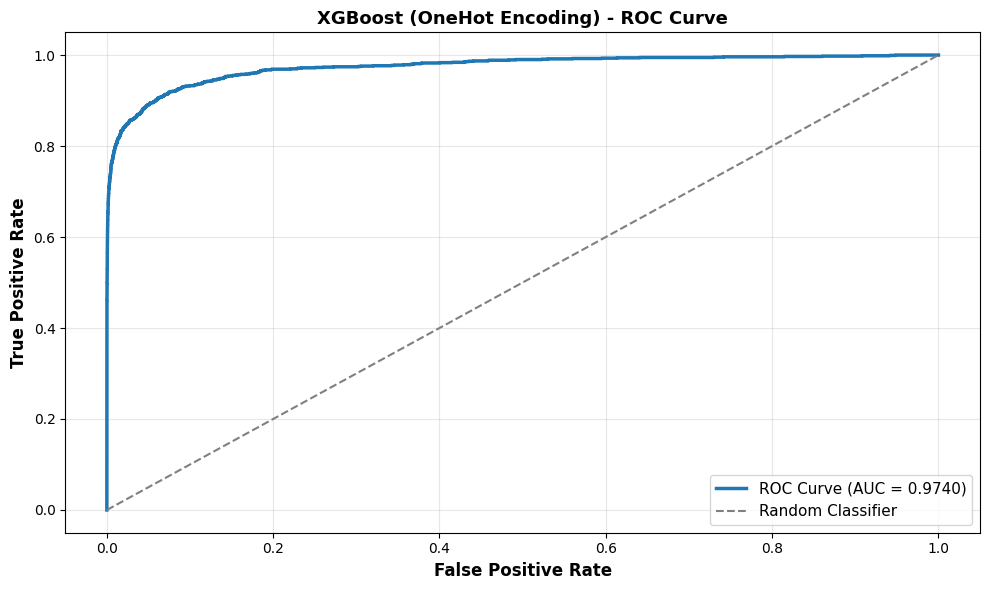

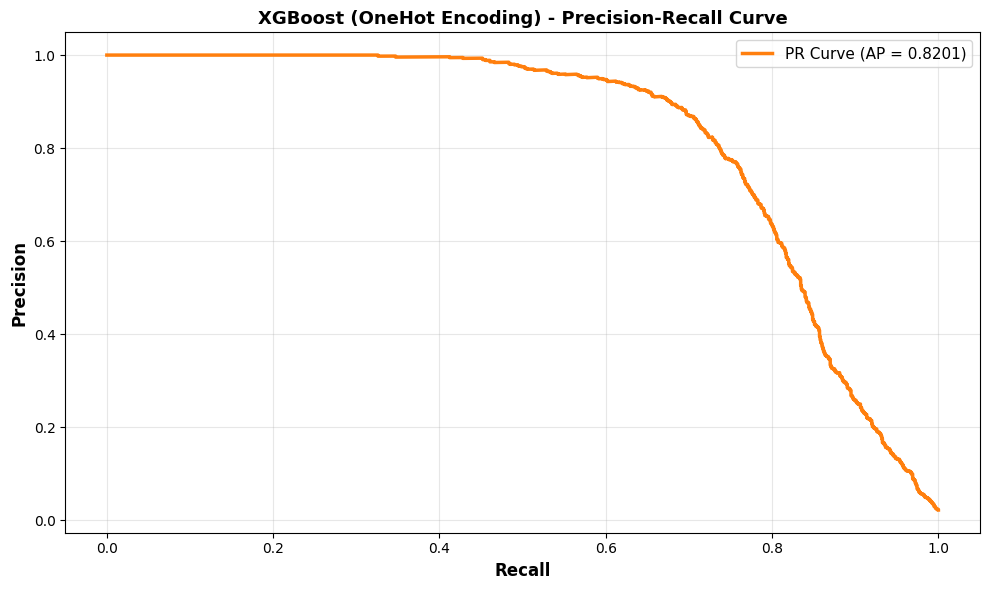

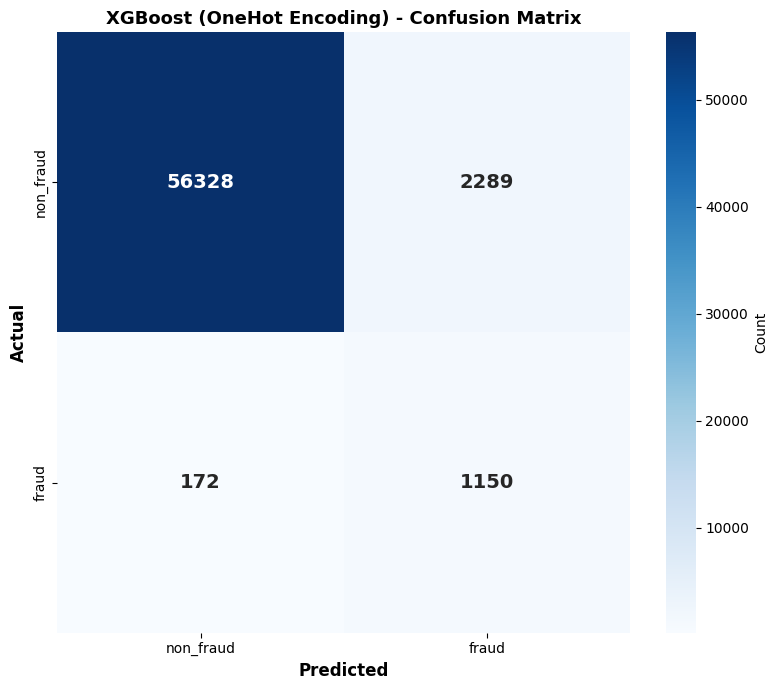

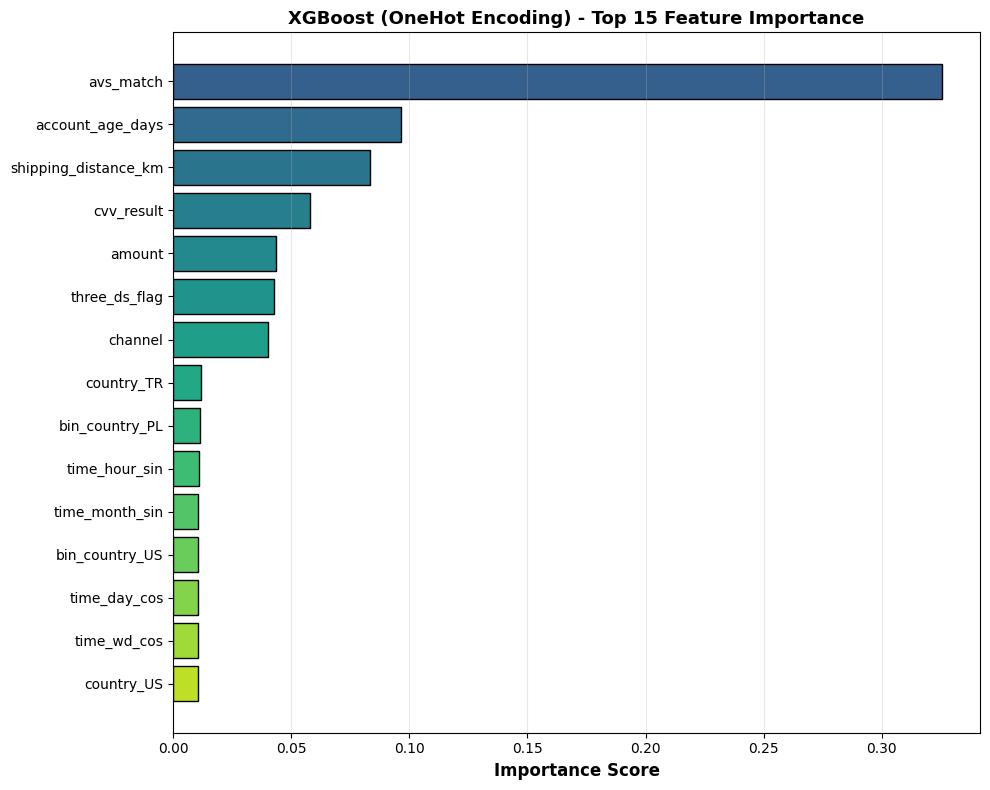

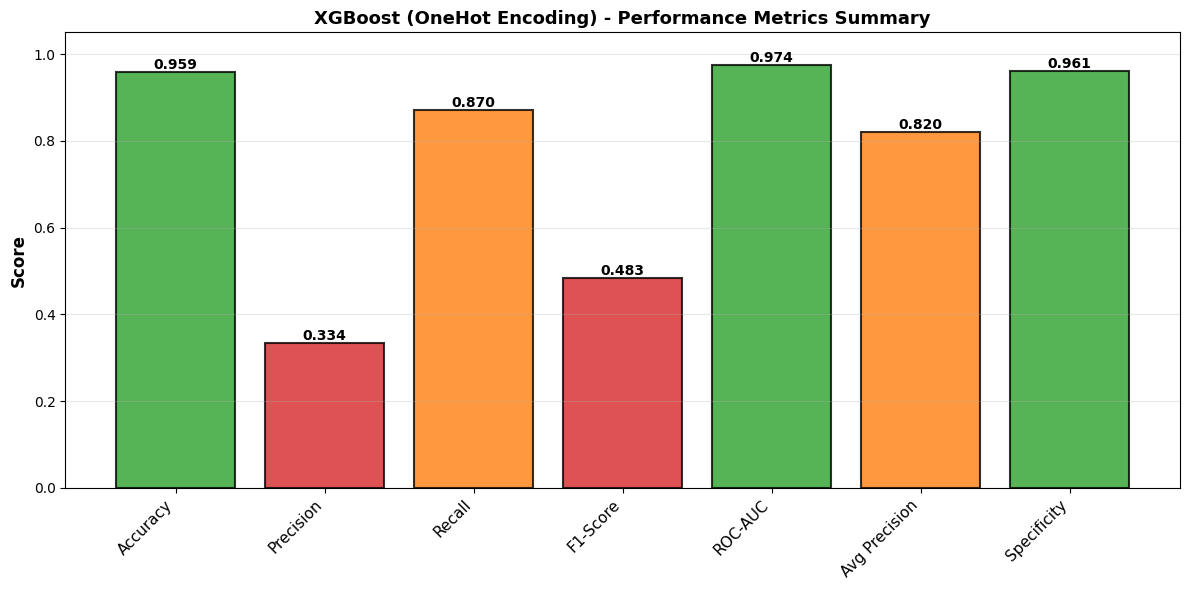

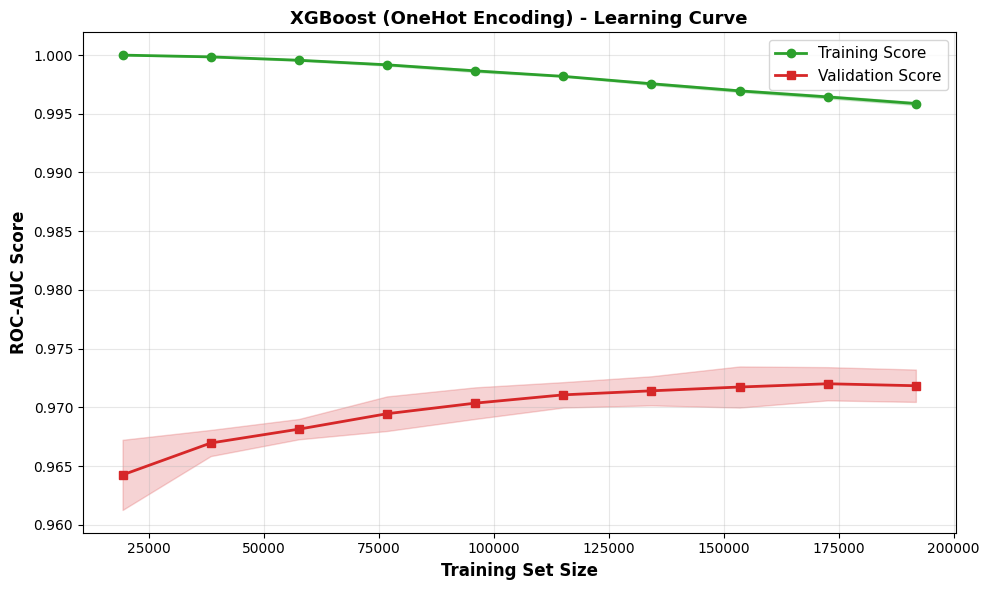


EVALUATION SUMMARY - XGBoost (OneHot Encoding)
Confusion Matrix Breakdown:
  True Negatives:     56328 | False Positives:     2289
  False Negatives:      172 | True Positives:      1150

Key Metrics:
  Sensitivity (Recall):  0.8699 (Fraud Detection Rate)
  Specificity:           0.9609 (Non-Fraud Identification)
  Precision:             0.3344 (Fraud Alarm Accuracy)
  False Alarm Rate:      0.0391
  ROC-AUC:               0.9740
  Average Precision:     0.8201


ENCODER COMPARISON HEATMAP



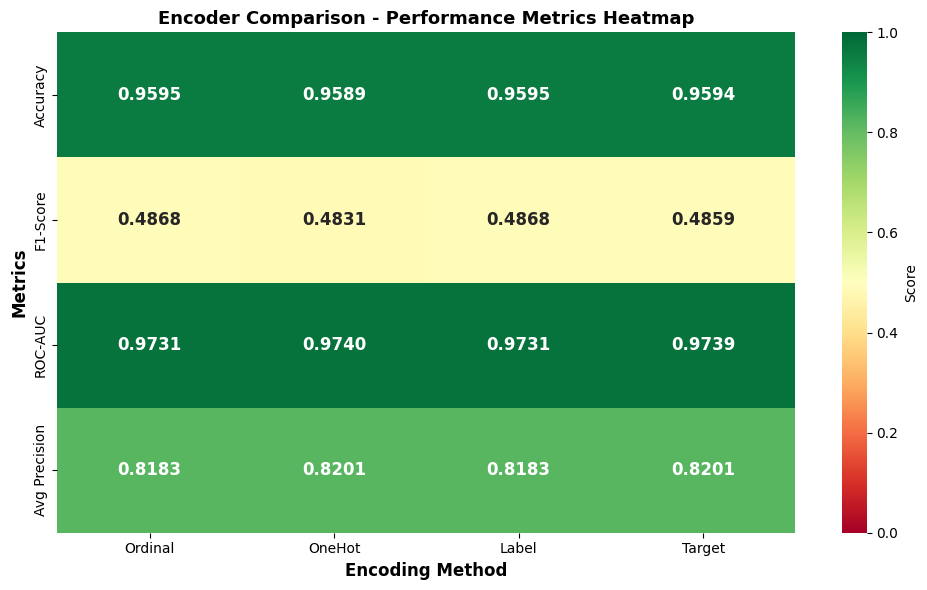

In [ ]:
# Visualising results for the best encoder only
print(f"VISUALIZATION: {best_encoder_name} Encoding (Best Encoder)")

# Retrieving best encoder model and training data
best_model = comparison_results[best_encoder_name]["model"]
best_X_train = comparison_results[best_encoder_name]["X_train_enc"]

# best encoder results with learning curve
visualize_results(
    comparison_results[best_encoder_name]["results"],
    title_prefix=f"XGBoost ({best_encoder_name} Encoding)",
    model=best_model,
    X_train=best_X_train,
    y_train=y_train
)

# encoder comparison heatmap
print("ENCODER COMPARISON HEATMAP")
visualize_encoder_comparison(comparison_results)

---

## 7. Business Impact Analysis

Translate technical metrics into business value: fraud prevented, operational costs, and ROI.

In [ ]:
def calculate_business_impact(results, avg_fraud_amount=500, false_positive_cost=25,
                              total_transactions=None, y_test=None):
    cm = results['confusion_matrix']
    tp = cm['true_positives']
    fp = cm['false_positives']
    fn = cm['false_negatives']
    tn = cm['true_negatives']

    # Financial calculations
    fraud_prevented = tp * avg_fraud_amount
    fraud_missed = fn * avg_fraud_amount
    false_alarm_cost = fp * false_positive_cost

    # Net benefit
    gross_savings = fraud_prevented
    operational_cost = false_alarm_cost
    net_savings = gross_savings - operational_cost

    # ROI
    roi_percentage = (net_savings / operational_cost * 100) if operational_cost > 0 else 0

    # Business rates
    fraud_catch_rate = (tp / (tp + fn) * 100) if (tp + fn) > 0 else 0
    precision_on_fraud = (tp / (tp + fp) * 100) if (tp + fp) > 0 else 0

    business_metrics = {
        'confusion_matrix_counts': {
            'frauds_caught': tp,
            'frauds_missed': fn,
            'false_alarms': fp,
            'correct_non_fraud': tn
        },
        'financial_impact': {
            'fraud_prevented_amount': f"${fraud_prevented:,.2f}",
            'fraud_missed_amount': f"${fraud_missed:,.2f}",
            'false_alarm_costs': f"${false_alarm_cost:,.2f}",
            'net_savings': f"${net_savings:,.2f}"
        },
        'business_metrics': {
            'fraud_detection_rate': f"{fraud_catch_rate:.2f}%",
            'precision_when_flagging_fraud': f"{precision_on_fraud:.2f}%",
            'roi_percentage': f"{roi_percentage:.2f}%"
        },
        'interpretation': {
            'frauds_caught': f"Prevented {tp} fraudulent transactions worth ${fraud_prevented:,.2f}",
            'frauds_missed': f"Missed {fn} frauds resulting in ${fraud_missed:,.2f} loss",
            'false_alarms': f"Generated {fp} false alarms costing ${false_alarm_cost:,.2f} to review",
            'bottom_line': f"Net savings: ${net_savings:,.2f} (ROI: {roi_percentage:.2f}%)"
        }
    }

    return business_metrics


# CALCULATE BUSINESS IMPACT
print("BUSINESS IMPACT ANALYSIS")

# Business assumptions
AVG_FRAUD_AMOUNT = 500
FALSE_POSITIVE_COST = 25
MANUAL_REVIEW_CAPACITY = 100

print(f"\nBusiness Assumptions:")
print(f"  Average Fraud Amount: ${AVG_FRAUD_AMOUNT}")
print(f"  False Positive Review Cost: ${FALSE_POSITIVE_COST}")
print(f"  Manual Review Capacity: {MANUAL_REVIEW_CAPACITY} transactions/day")

# Calculating impact
best_results = comparison_results[best_encoder_name]['results']
business_impact = calculate_business_impact(
    best_results,
    avg_fraud_amount=AVG_FRAUD_AMOUNT,
    false_positive_cost=FALSE_POSITIVE_COST,
    y_test=y_test
)

print("FINANCIAL IMPACT")
for key, value in business_impact['financial_impact'].items():
    print(f"  {key.replace('_', ' ').title()}: {value}")

print("BUSINESS METRICS")
for key, value in business_impact['business_metrics'].items():
    print(f"  {key.replace('_', ' ').title()}: {value}")

print("INTERPRETATION")
for key, value in business_impact['interpretation'].items():
    print(f"{value}")

BUSINESS IMPACT ANALYSIS

Business Assumptions:
  Average Fraud Amount: $500
  False Positive Review Cost: $25
  Manual Review Capacity: 100 transactions/day

--------------------------------------------------------------------------------
FINANCIAL IMPACT
--------------------------------------------------------------------------------
  Fraud Prevented Amount: $575,000.00
  Fraud Missed Amount: $86,000.00
  False Alarm Costs: $57,225.00
  Net Savings: $517,775.00

--------------------------------------------------------------------------------
BUSINESS METRICS
--------------------------------------------------------------------------------
  Fraud Detection Rate: 86.99%
  Precision When Flagging Fraud: 33.44%
  Roi Percentage: 904.81%

--------------------------------------------------------------------------------
INTERPRETATION
--------------------------------------------------------------------------------
  ✓ Prevented 1150 fraudulent transactions worth $575,000.00
  ✓ Missed 172 

In [ ]:
# FINAL SUMMARY
print("SAVING MODEL RESULTS")

# best model results
best_results_data = comparison_results[best_encoder_name]['results']

# key information
cm = best_results_data["confusion_matrix"]
roc_data = best_results_data["roc_curve"]
pr_data = best_results_data["precision_recall_curve"]

# Encoder comparison summary
encoder_summary = {}
for encoder_name, data in comparison_results.items():
    encoder_summary[encoder_name] = {
        "accuracy": data["results"]["performance_metrics"]["accuracy"],
        "f1_score": data["results"]["performance_metrics"]["f1_score"],
        "roc_auc": data["results"]["performance_metrics"]["roc_auc"],
        "average_precision": data["results"]["performance_metrics"]["average_precision"]
    }

# classification report
class_report = best_results_data["classification_report"]

final_results = {
    "best_encoder": best_encoder_name,
    "encoder_comparison": encoder_summary,
    "classification_report": class_report,
    "roc_auc": best_results_data["performance_metrics"]["roc_auc"],
    "average_precision": best_results_data["performance_metrics"]["average_precision"],
    "confusion_matrix": cm,
    "roc_curve": roc_data,
    "precision_recall_curve": pr_data,
    "business_impact": business_impact
}

final_json_path = "results/xgboost_model_evaluation.json"
with open(final_json_path, 'w') as f:
    json.dump(final_results, f, indent=4)

print(f"\nBest Encoder: {best_encoder_name}")
print(f"ROC-AUC: {best_results_data['performance_metrics']['roc_auc']:.4f}")
print(f"Avg Precision: {best_results_data['performance_metrics']['average_precision']:.4f}")
print(f"\n Results saved to: {final_json_path}")
print("Model training and evaluation completed successfully!")

SAVING MODEL RESULTS

✓ Best Encoder: OneHot
✓ ROC-AUC: 0.9740
✓ Avg Precision: 0.8201

✓ Results saved to: xgboost_model_evaluation.json
Model training and evaluation completed successfully!
